# Adult sex CMAB fairness

This notebook runs the Adult Income experiments with sex as the sensitive attribute in the contextual multi-armed bandit framework used in the thesis.

The objective is to compare three families of contextual bandit algorithms:

- **LinUCB family**: LinUCB and FairLinUCB;
- **Linear Thompson Sampling family**: LinTS and FairLinTS;
- **EXP4 family**: EXP4 and FairEXP4.

For each family, the notebook evaluates three levels of fairness intervention:

- **Pre-processing**: uniform weighting versus group-label reweighting;
- **In-processing**: standard policy versus demographic-parity-aware policy;
- **Post-processing**: group-specific threshold calibration on held-out data.

The binary action is interpreted as the predicted Adult income class. The reward is equal to 1 when the selected action matches the observed label and 0 otherwise. Therefore, average reward is equivalent to accuracy in this offline classification-derived bandit setting.

The main utility metrics are average reward and cumulative prediction error. Fairness is assessed using Demographic Parity Gap, Equalized Odds Gap, and UtilityGap. Temporal figures report the evolution of these metrics over the learning horizon.

In [22]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    """
    Find the repository root from the current notebook location.

    This lets the notebook run both from VS Code and from Jupyter, whether the
    current working directory is the project root or a subfolder such as notebooks/.
    """
    current = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "src" / "fair_bandits").exists():
            return candidate
        if (candidate / "fair_bandits").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from fair_bandits.config import build_config

from fair_bandits.data import (
    load_adult,
    prepare_adult_sex_splits,
)

from fair_bandits.experiments import (
    AdultBanditParams,
    load_adult_family_outputs,
    run_adult_family_benchmark,
    train_adult_expert_pool,
)

from fair_bandits.io import (
    export_adult_final_summary_tables,
    export_adult_significance_tables,
)

from fair_bandits.metrics import normalize_metric_columns

from fair_bandits.plots import (
    plot_adult_family_figure_set,
    plot_adult_postprocessing_summary,
)

warnings.filterwarnings("ignore", category=FutureWarning)

## Configuration

This section defines the run mode, output directories, random seeds, horizon, policy families, preprocessing settings, and hyperparameters.

For reproducibility, the notebook is designed to either regenerate the full benchmark or reload cached outputs.

In [23]:
RUN_MODE = "full"  # use "full" for thesis results
RUN_BENCHMARK = True
FORCE_RERUN = False

try:
    CFG = build_config(
        run_mode="full" if RUN_MODE == "full" else "dev",
    )
except TypeError:
    CFG = build_config(
        "full" if RUN_MODE == "full" else "dev",
    )

RESULTS_ROOT = Path(CFG.results_dir)
OUTPUT_ROOT = RESULTS_ROOT / "adult_sex_cmab_refactored"
RUN_DIR = OUTPUT_ROOT / RUN_MODE
FIG_DIR = OUTPUT_ROOT / "final_figures"
TABLE_DIR = OUTPUT_ROOT / "overleaf_tables"

ADULT_CSV_CANDIDATES = [
    PROJECT_ROOT / "data_cache" / "adult.csv",
    PROJECT_ROOT / "data_cache" / "adult.data",
    PROJECT_ROOT / "notebooks" / "data_cache" / "adult.csv",
    PROJECT_ROOT / "notebooks" / "data_cache" / "adult.data",
    PROJECT_ROOT / "data" / "adult.csv",
    PROJECT_ROOT / "data" / "adult.data",
    PROJECT_ROOT / "datasets" / "adult.csv",
    PROJECT_ROOT / "datasets" / "adult.data",
    Path.home() / "Downloads" / "adult.csv",
    Path.home() / "Downloads" / "adult.data",
]

ADULT_CSV_PATH = next(
    (
        path
        for path in ADULT_CSV_CANDIDATES
        if path.exists()
    ),
    None,
)

if ADULT_CSV_PATH is None:
    print("No local Adult CSV/data file found.")
    print("Loading Adult from OpenML through fair_bandits.data.load_adult().")

    adult_df = load_adult()

    print("Downloaded Adult dataframe:", adult_df.shape)
    print("Columns:", adult_df.columns.tolist())

else:
    print("ADULT_CSV_PATH:", ADULT_CSV_PATH)

print("ADULT_CSV_PATH:", ADULT_CSV_PATH)

PREPROCESSINGS = [
    "uniform",
    "reweigh_group_label",
]

PREPROCESSING_LABELS = {
    "uniform": "Uniform",
    "reweigh_group_label": "Reweighting",
}

POLICY_FAMILIES = {
    "linucb": {
        "label": "LinUCB",
        "policies": ["LinUCB", "FairLinUCB"],
        "postprocessed_policy": "FairLinUCB+PP",
    },
    "linear_ts": {
        "label": "Linear Thompson Sampling",
        "policies": ["LinTS", "FairLinTS"],
        "postprocessed_policy": "FairLinTS+PP",
    },
    "exp4": {
        "label": "EXP4",
        "policies": ["EXP4", "FairEXP4"],
        "postprocessed_policy": "FairEXP4+PP",
    },
}

POLICY_LABELS = {
    "LinUCB": "LinUCB",
    "FairLinUCB": "FairLinUCB",
    "FairLinUCB+PP": "FairLinUCB+PP",
    "LinTS": "LinTS",
    "FairLinTS": "FairLinTS",
    "FairLinTS+PP": "FairLinTS+PP",
    "EXP4": "EXP4",
    "FairEXP4": "FairEXP4",
    "FairEXP4+PP": "FairEXP4+PP",
}

if RUN_MODE == "dev":
    N_SEEDS = 2
    T_MAX = 1500
    LOG_EVERY = 25
    N_EXPERTS = 8
    EXPERT_BOOTSTRAP_SIZE = 6000
else:
    N_SEEDS = 50
    T_MAX = 30000
    LOG_EVERY = 50
    N_EXPERTS = 20
    EXPERT_BOOTSTRAP_SIZE = 12000

SEEDS = list(range(N_SEEDS))

TEST_SIZE = 0.20
CALIBRATION_SIZE_WITHIN_REMAINING = 0.20

LAMBDA_RIDGE = 10.0
ALPHA_LINUCB = 1.5
TS_V = 0.25

EXP4_GAMMA = 0.07
EXP4_ETA = None

DP_TAU = 0.02
DP_LAMBDA = 2.0
BETA_SMOOTH = 1.0
MIN_GROUP_COUNT = 20

MAX_ACCURACY_DROP = 0.01
THRESHOLD_GRID_SIZE = 31

print("RUN_MODE:", RUN_MODE)
print("RUN_DIR:", RUN_DIR)
print("FIG_DIR:", FIG_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("N_SEEDS:", N_SEEDS)
print("T_MAX:", T_MAX)
print("RUN_BENCHMARK:", RUN_BENCHMARK)

No local Adult CSV/data file found.
Loading Adult from OpenML through fair_bandits.data.load_adult().
Downloaded Adult dataframe: (48842, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
ADULT_CSV_PATH: None
RUN_MODE: full
RUN_DIR: results\full\adult_sex_cmab_refactored\full
FIG_DIR: results\full\adult_sex_cmab_refactored\final_figures
TABLE_DIR: results\full\adult_sex_cmab_refactored\overleaf_tables
N_SEEDS: 50
T_MAX: 30000
RUN_BENCHMARK: True


## Load and prepare Adult sex dataset

The Adult dataset is loaded either from a local CSV/data file or, if no local file is found, through the existing `load_adult()` helper.

The dataset is then prepared with sex as the sensitive attribute. The target is encoded as a binary income label, the feature matrix is one-hot encoded and standardized, and the data are split into train, calibration, and test subsets. The split is stratified by group-label strata so that both sensitive-group and label distributions remain stable across subsets.

In [24]:
adult_data = prepare_adult_sex_splits(
    adult_csv_path=ADULT_CSV_PATH,
    in_memory_frames=globals(),
    test_size=TEST_SIZE,
    calibration_size_within_remaining=CALIBRATION_SIZE_WITHIN_REMAINING,
)

print("\nTrain target proportion:")
display(
    pd.Series(adult_data.y_train)
    .value_counts(normalize=True)
    .rename("proportion")
)

print("\nTrain group proportion:")
display(
    pd.Series(adult_data.g_train)
    .value_counts(normalize=True)
    .rename("proportion")
)

print("\nTrain group × target:")
display(
    pd.crosstab(
        adult_data.g_train,
        adult_data.y_train,
        normalize="index",
    ).round(4)
)

Using in-memory dataframe: adult_df
Prepared X: (48842, 109)
Train: (31258, 109) Calibration: (7815, 109) Test: (9769, 109)
Groups: ['Female', 'Male']

Train target proportion:


0    0.760733
1    0.239267
Name: proportion, dtype: float64


Train group proportion:


Male      0.668501
Female    0.331499
Name: proportion, dtype: float64


Train group × target:


col_0,0,1
row_0,,
Female,0.8908,0.1092
Male,0.6963,0.3037


## Train EXP4 expert pool

The EXP4 family requires expert advice. When the benchmark is regenerated, a supervised expert pool is trained on the Adult training set and converted into action-advice matrices for the train, calibration, and test sets.

When cached benchmark outputs are loaded, this step is skipped because the stored EXP4 results already contain the trajectories and final metrics.

In [25]:
expert_pool = train_adult_expert_pool(
    adult_data.X_train,
    adult_data.y_train,
    n_experts=N_EXPERTS,
    bootstrap_size=EXPERT_BOOTSTRAP_SIZE,
    seed=2026,
)

ADVICE_TRAIN = expert_pool.predict_advice(adult_data.X_train)
ADVICE_CAL = expert_pool.predict_advice(adult_data.X_cal)
ADVICE_TEST = expert_pool.predict_advice(adult_data.X_test)

print("ADVICE_TRAIN:", ADVICE_TRAIN.shape)
print("ADVICE_CAL:", ADVICE_CAL.shape)
print("ADVICE_TEST:", ADVICE_TEST.shape)

ADVICE_TRAIN: (31258, 20, 2)
ADVICE_CAL: (7815, 20, 2)
ADVICE_TEST: (9769, 20, 2)


## Run or load Adult policy-family benchmarks

This section runs or loads the Adult-sex contextual bandit experiments for the three policy families.

For LinUCB and LinTS, reweighting affects the update weights. For EXP4, reweighting affects the sampled training stream. This preserves the behaviour of the original notebooks while using a common module-based workflow.

Each family is evaluated across both preprocessing settings, all random seeds, and the full learning horizon. The outputs are concatenated into shared temporal, endpoint, post-processing, and parameter dataframes.

In [26]:
params = AdultBanditParams(
    d=adult_data.X_train.shape[1],
    t_max=T_MAX,
    log_every=LOG_EVERY,
    alpha_linucb=ALPHA_LINUCB,
    ts_v=TS_V,
    lambda_ridge=LAMBDA_RIDGE,
    exp4_gamma=EXP4_GAMMA,
    exp4_eta=EXP4_ETA,
    n_experts=N_EXPERTS,
    dp_tau=DP_TAU,
    dp_lambda=DP_LAMBDA,
    beta_smooth=BETA_SMOOTH,
    min_group_count=MIN_GROUP_COUNT,
    max_accuracy_drop=MAX_ACCURACY_DROP,
    threshold_grid_size=THRESHOLD_GRID_SIZE,
)

all_temporal = []
all_endpoint = []
all_postproc = []
all_parameters = []

for family, family_config in POLICY_FAMILIES.items():
    print("\nFamily:", family)
    family_run_dir = RUN_DIR / family

    if RUN_BENCHMARK:
        temporal_df, endpoint_df, postproc_df, parameters_df = run_adult_family_benchmark(
            family=family,
            run_dir=family_run_dir,
            X_train=adult_data.X_train,
            y_train=adult_data.y_train,
            g_train=adult_data.g_train,
            X_cal=adult_data.X_cal,
            y_cal=adult_data.y_cal,
            g_cal=adult_data.g_cal,
            X_test=adult_data.X_test,
            y_test=adult_data.y_test,
            g_test=adult_data.g_test,
            advice_train=ADVICE_TRAIN if family == "exp4" else None,
            advice_cal=ADVICE_CAL if family == "exp4" else None,
            advice_test=ADVICE_TEST if family == "exp4" else None,
            preprocessings=PREPROCESSINGS,
            policies=family_config["policies"],
            seeds=SEEDS,
            params=params,
            force_rerun=FORCE_RERUN,
        )
    else:
        temporal_df, endpoint_df, postproc_df, parameters_df = load_adult_family_outputs(
            family=family,
            run_dir=family_run_dir,
        )

    all_temporal.append(temporal_df)
    all_endpoint.append(endpoint_df)
    all_postproc.append(postproc_df)
    all_parameters.append(parameters_df)

adult_temporal_df = normalize_metric_columns(pd.concat(all_temporal, ignore_index=True))
adult_endpoint_df = normalize_metric_columns(pd.concat(all_endpoint, ignore_index=True))
adult_postproc_df = normalize_metric_columns(pd.concat(all_postproc, ignore_index=True))
adult_parameters_df = pd.concat(all_parameters, ignore_index=True)

print("\nTemporal:", adult_temporal_df.shape)
print("Endpoint:", adult_endpoint_df.shape)
print("Post-processing:", adult_postproc_df.shape)
print("Parameters:", adult_parameters_df.shape)


Family: linucb
Cached: linucb (0, 'uniform', 'LinUCB')
Cached: linucb (0, 'uniform', 'FairLinUCB')
Cached post-processing: linucb (0, 'uniform')
Cached: linucb (0, 'reweigh_group_label', 'LinUCB')
Cached: linucb (0, 'reweigh_group_label', 'FairLinUCB')
Cached post-processing: linucb (0, 'reweigh_group_label')
Cached: linucb (1, 'uniform', 'LinUCB')
Cached: linucb (1, 'uniform', 'FairLinUCB')
Cached post-processing: linucb (1, 'uniform')
Cached: linucb (1, 'reweigh_group_label', 'LinUCB')
Cached: linucb (1, 'reweigh_group_label', 'FairLinUCB')
Cached post-processing: linucb (1, 'reweigh_group_label')
Cached: linucb (2, 'uniform', 'LinUCB')
Cached: linucb (2, 'uniform', 'FairLinUCB')
Cached post-processing: linucb (2, 'uniform')
Cached: linucb (2, 'reweigh_group_label', 'LinUCB')
Cached: linucb (2, 'reweigh_group_label', 'FairLinUCB')
Cached post-processing: linucb (2, 'reweigh_group_label')
Cached: linucb (3, 'uniform', 'LinUCB')
Cached: linucb (3, 'uniform', 'FairLinUCB')
Cached post-

## Validate benchmark outputs

This section checks that the expected families, policies, preprocessing settings, seeds, and final horizons are present in the loaded or newly generated results.

These checks are useful before generating figures and statistical tables, because missing cached files or incomplete runs would otherwise produce misleading summaries.

In [27]:
print("Families:", sorted(adult_temporal_df["family"].unique()))
print("Policies:", sorted(adult_temporal_df["policy"].unique()))
print("Preprocessings:", sorted(adult_temporal_df["preprocessing"].unique()))
print("Seeds:", adult_temporal_df["seed"].nunique())
print("Final t values:", sorted(adult_endpoint_df["t"].unique()))

expected_endpoint_rows = (
    sum(len(config["policies"]) for config in POLICY_FAMILIES.values())
    * len(PREPROCESSINGS)
    * len(SEEDS)
)

expected_postproc_rows = (
    len(POLICY_FAMILIES)
    * len(PREPROCESSINGS)
    * len(SEEDS)
    * 2
)

print("Expected endpoint rows:", expected_endpoint_rows)
print("Observed endpoint rows:", len(adult_endpoint_df))
print("Expected post-processing rows:", expected_postproc_rows)
print("Observed post-processing rows:", len(adult_postproc_df))

display(adult_endpoint_df.head())
display(adult_postproc_df.head())

Families: ['exp4', 'linear_ts', 'linucb']
Policies: ['EXP4', 'FairEXP4', 'FairLinTS', 'FairLinUCB', 'LinTS', 'LinUCB']
Preprocessings: ['reweigh_group_label', 'uniform']
Seeds: 50
Final t values: [np.int64(30000)]
Expected endpoint rows: 600
Observed endpoint rows: 600
Expected post-processing rows: 600
Observed post-processing rows: 600


,family,t,seed,policy,preprocessing,accuracy,average_reward,cumulative_prediction_error,cumulative_regret,DP_gap,TPR_gap,FPR_gap,EO_gap,UtilityGap
0,linucb,30000,0,LinUCB,uniform,0.720367,0.720367,8389.0,8389.0,0.453157,0.224772,0.386499,0.386499,0.242896
1,linucb,30000,0,FairLinUCB,uniform,0.816600,0.816600,5502.0,5502.0,0.058265,0.158568,0.013305,0.158568,0.072800
2,linucb,30000,0,LinUCB,reweigh_group_label,0.705300,0.705300,8841.0,8841.0,0.432312,0.136938,0.373792,0.373792,0.230147
3,linucb,30000,0,FairLinUCB,reweigh_group_label,0.786433,0.786433,6407.0,6407.0,0.148466,0.068801,0.058539,0.068801,0.059403
4,linucb,30000,1,LinUCB,uniform,0.829833,0.829833,5105.0,5105.0,0.156193,0.081446,0.058305,0.081446,0.093033


,family,seed,preprocessing,policy,t,accuracy,average_reward,cumulative_prediction_error,cumulative_regret,DP_gap,TPR_gap,FPR_gap,EO_gap,UtilityGap
0,linucb,0,uniform,FairLinUCB,30000,0.821374,0.821374,1745.0,1745.0,0.035330,0.201186,0.031355,0.201186,0.071854
1,linucb,0,uniform,FairLinUCB+PP,30000,0.810011,0.810011,1856.0,1856.0,0.016491,0.192341,0.018057,0.192341,0.132269
2,linucb,0,reweigh_group_label,FairLinUCB,30000,0.803358,0.803358,1921.0,1921.0,0.086311,0.117619,0.009776,0.117619,0.022597
3,linucb,0,reweigh_group_label,FairLinUCB+PP,30000,0.803665,0.803665,1918.0,1918.0,0.007510,0.260385,0.024483,0.260385,0.149616
4,linucb,1,uniform,FairLinUCB,30000,0.805098,0.805098,1904.0,1904.0,0.074348,0.047846,0.002665,0.047846,0.072648


## Figures

This section generates the standard Adult-sex figure set for each policy family.

For each family, the notebook produces:

- a preprocessing comparison for Demographic Parity Gap and Equalized Odds Gap;
- an in-processing comparison under uniform preprocessing;
- temporal utility figures for average reward, cumulative prediction error, and UtilityGap;
- held-out post-processing summary figures.

The visual convention is kept consistent across families: baseline policies are blue, fairness-aware policies are red, post-processed policies are green, uniform preprocessing is shown with solid lines, and reweighting with dotted lines. Temporal bands indicate pointwise 95% confidence intervals for the mean trajectory across seeds.

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_preprocessing_fairness.png


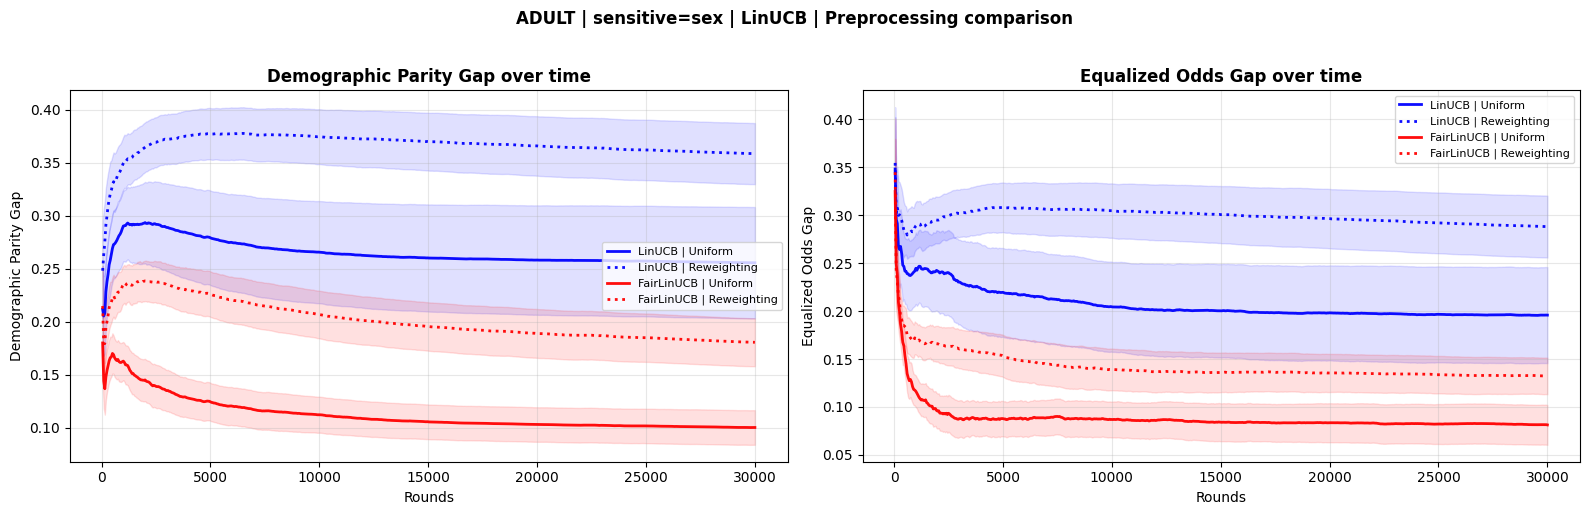

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_inprocessing_fairness.png


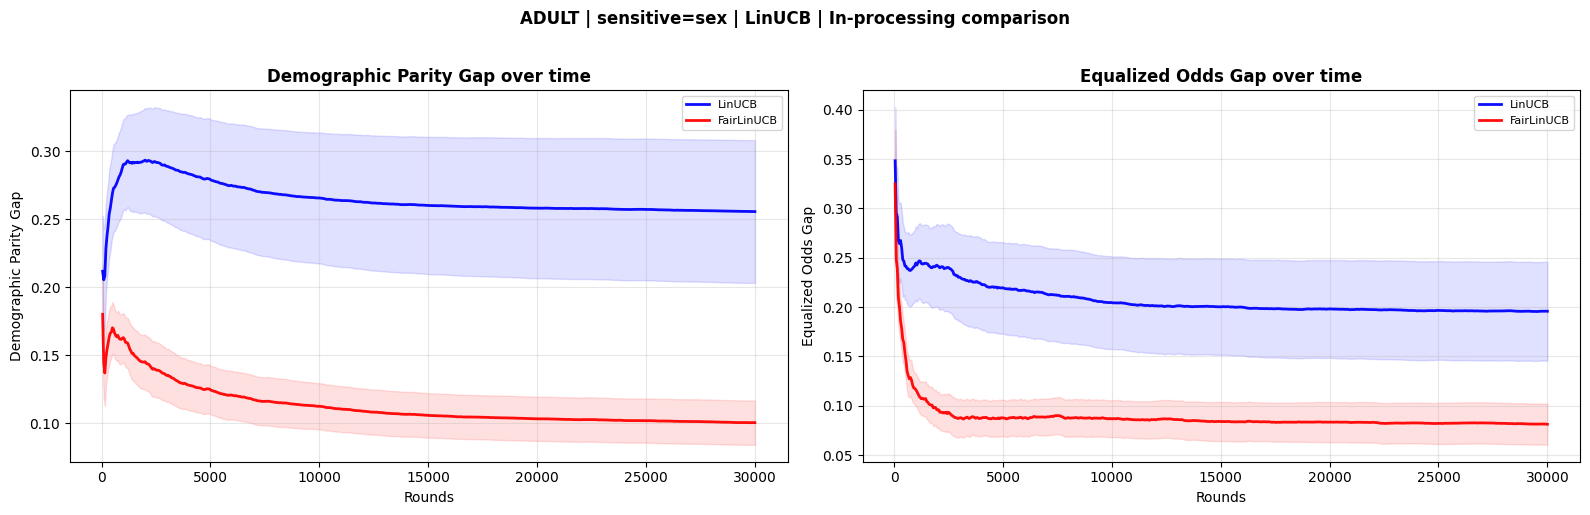

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_average_reward.png


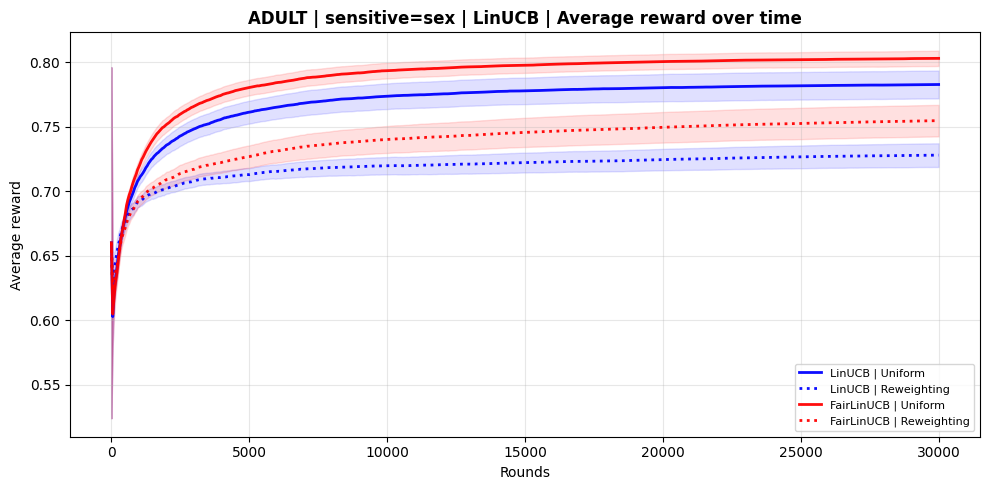

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_cumulative_prediction_error.png


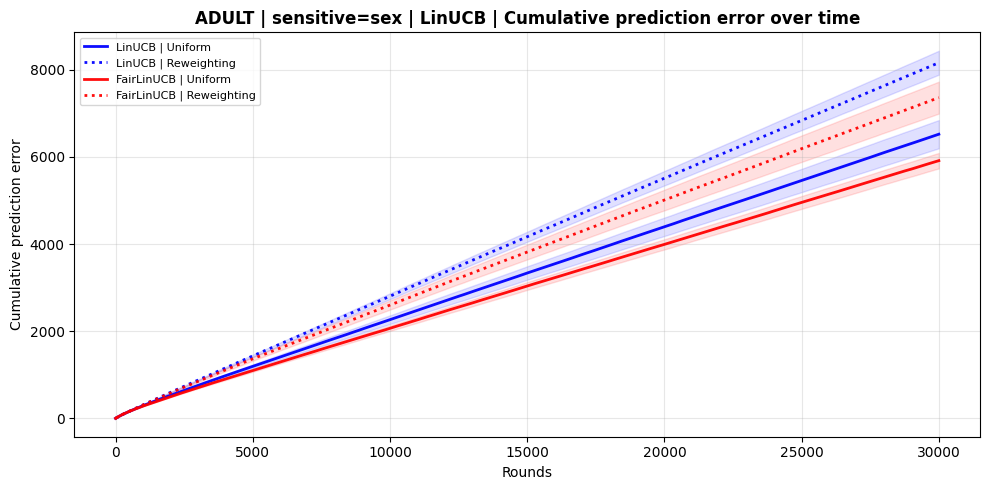

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_utility_gap.png


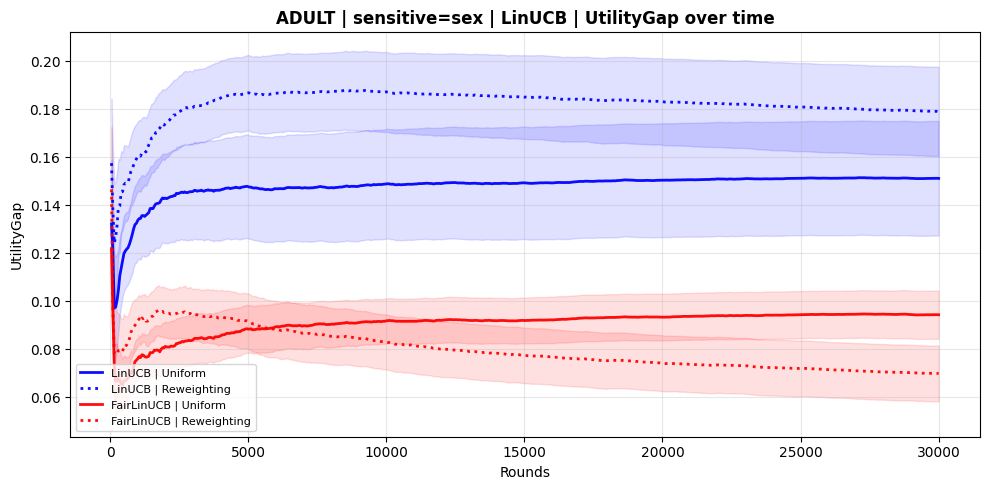

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_postprocessing_dp_gap.png


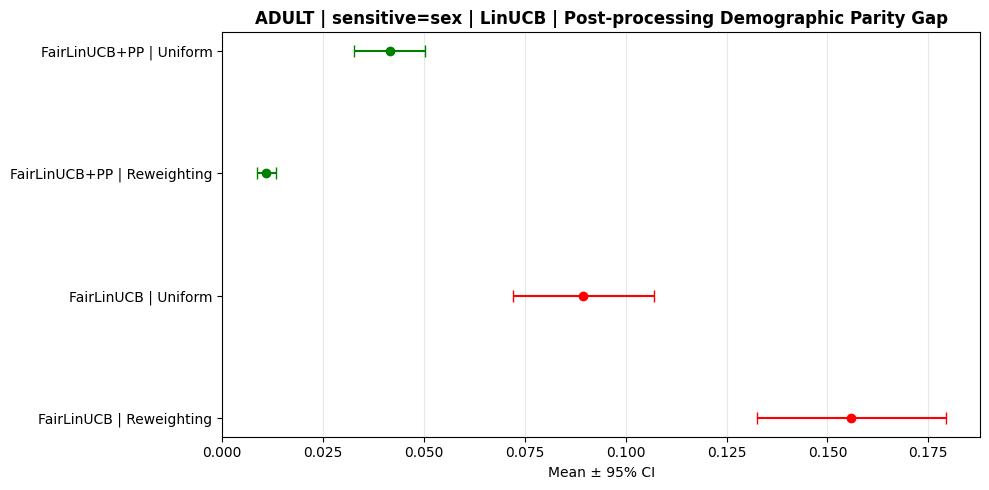

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_postprocessing_eo_gap.png


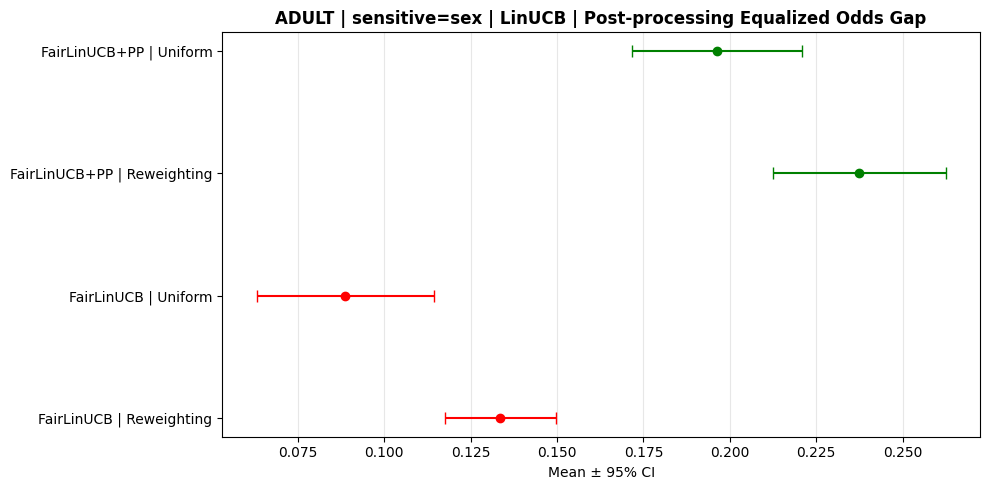

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_postprocessing_average_reward.png


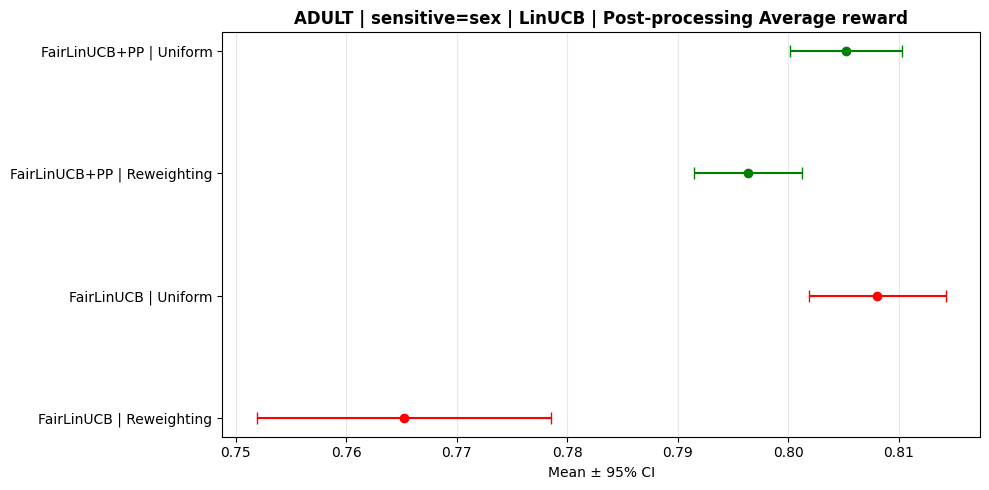

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_preprocessing_fairness.png


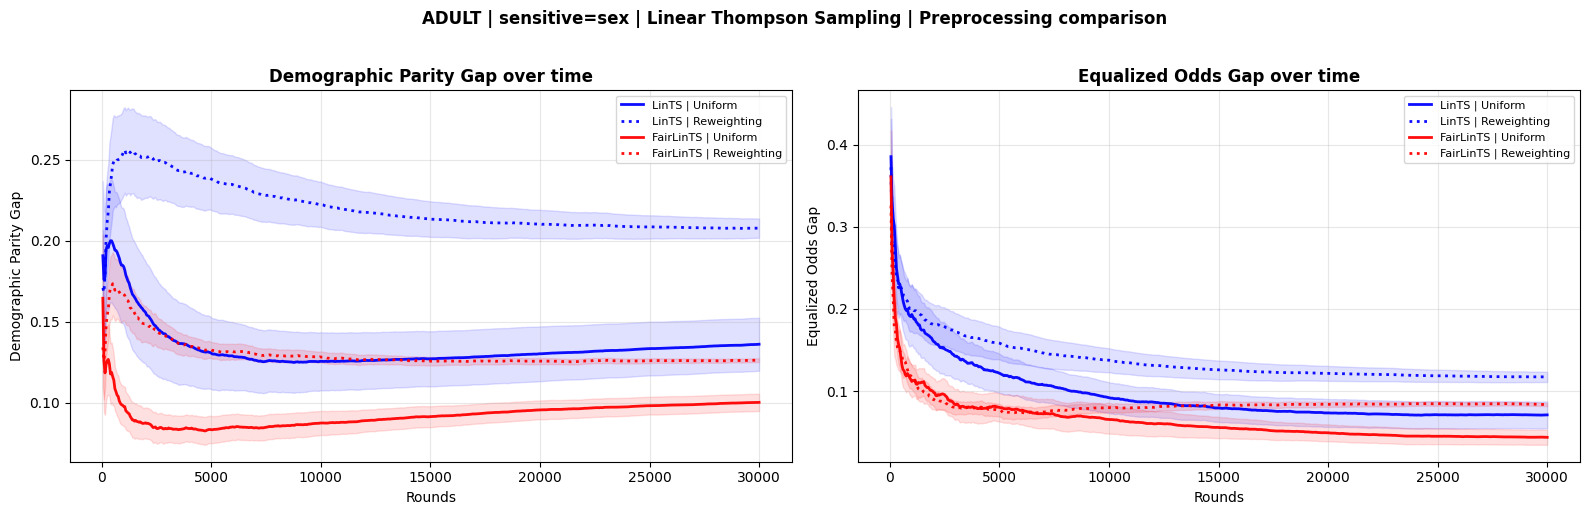

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_inprocessing_fairness.png


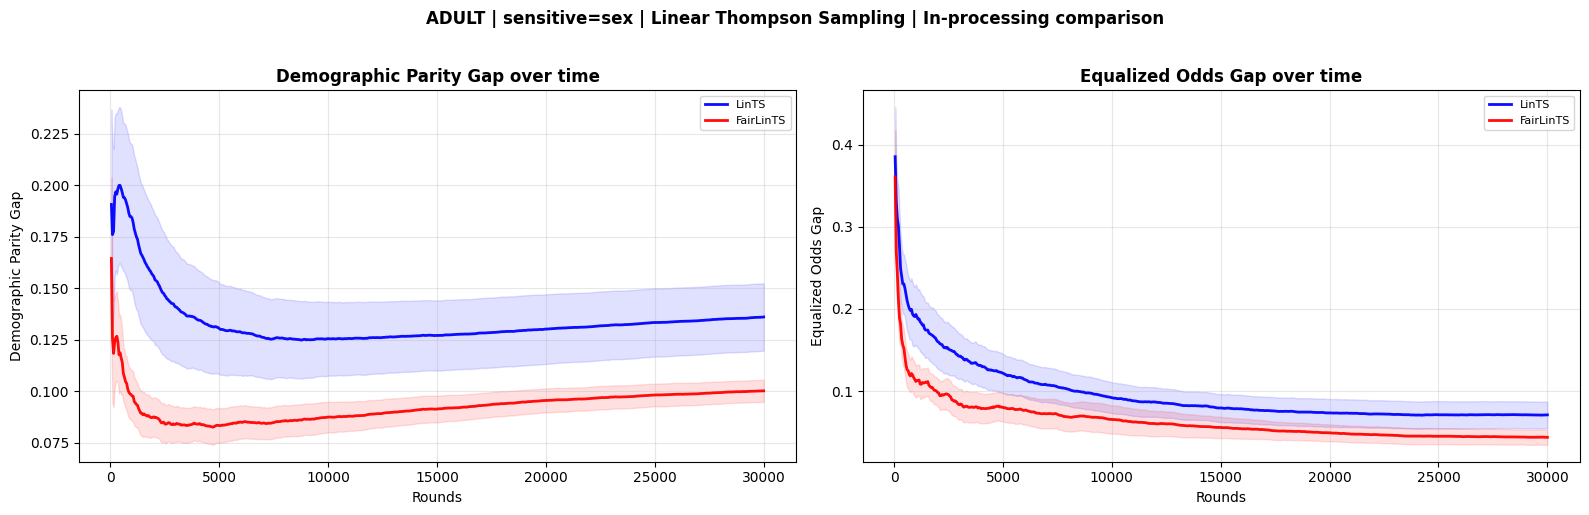

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_average_reward.png


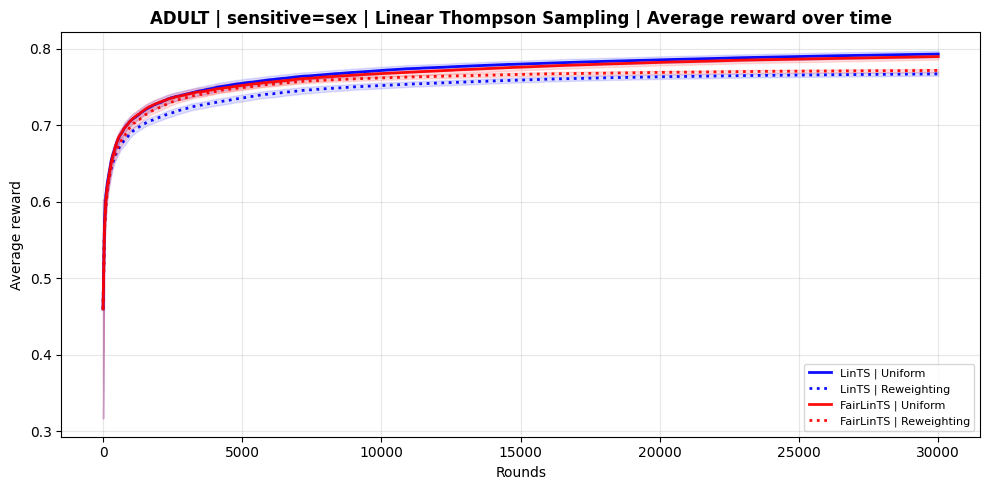

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_cumulative_prediction_error.png


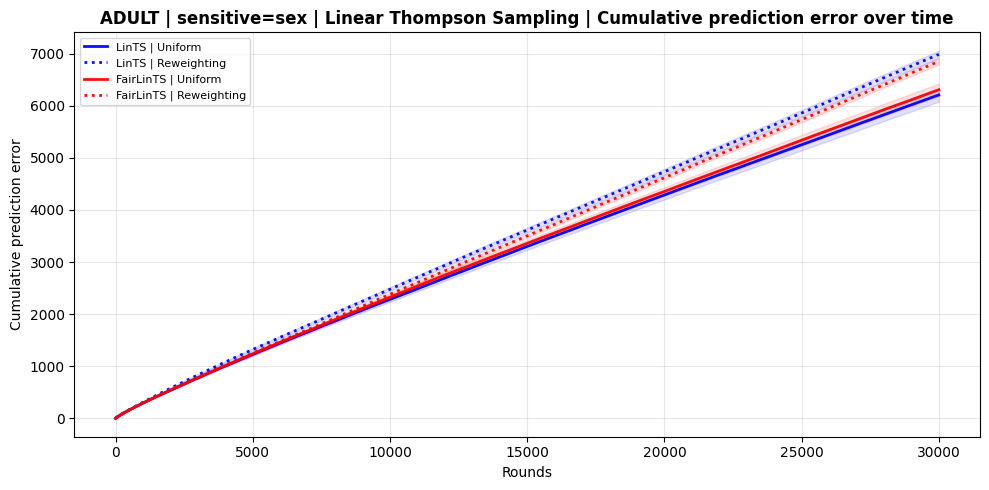

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_utility_gap.png


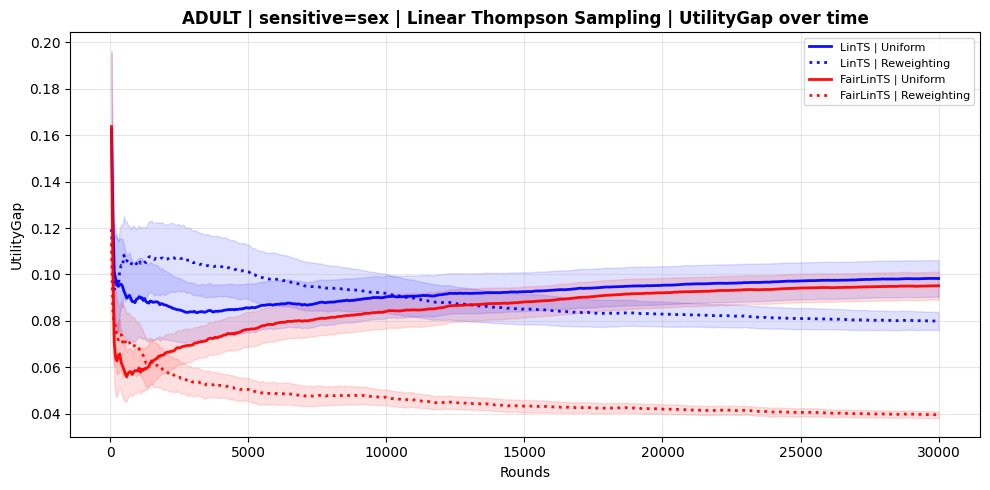

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_postprocessing_dp_gap.png


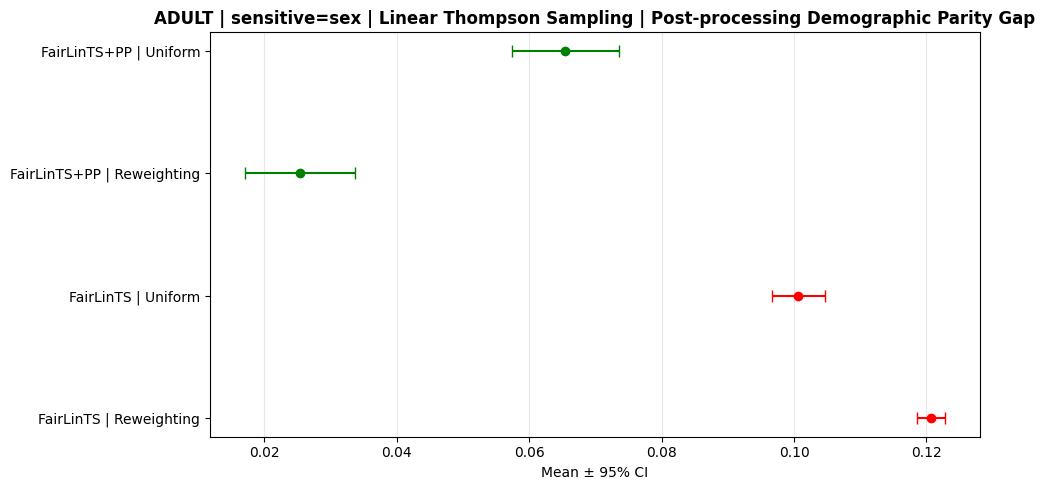

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_postprocessing_eo_gap.png


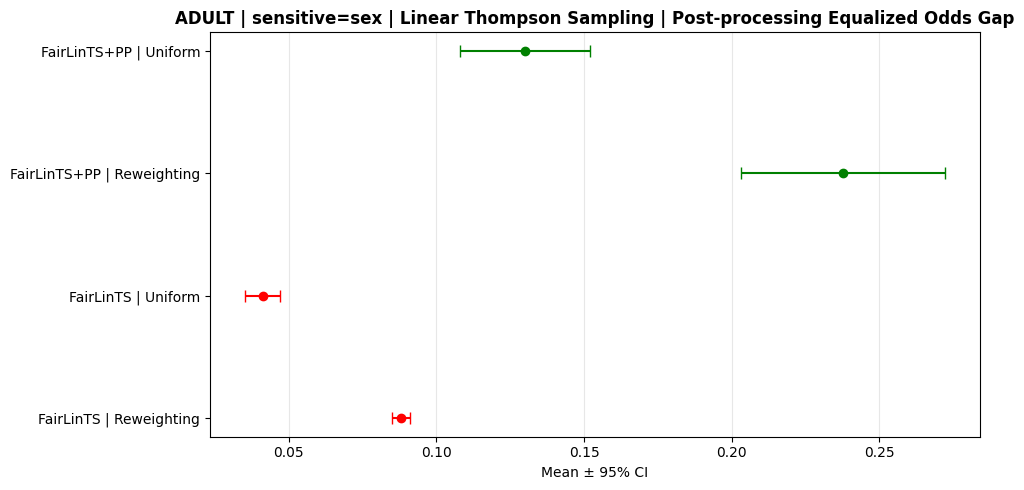

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_postprocessing_average_reward.png


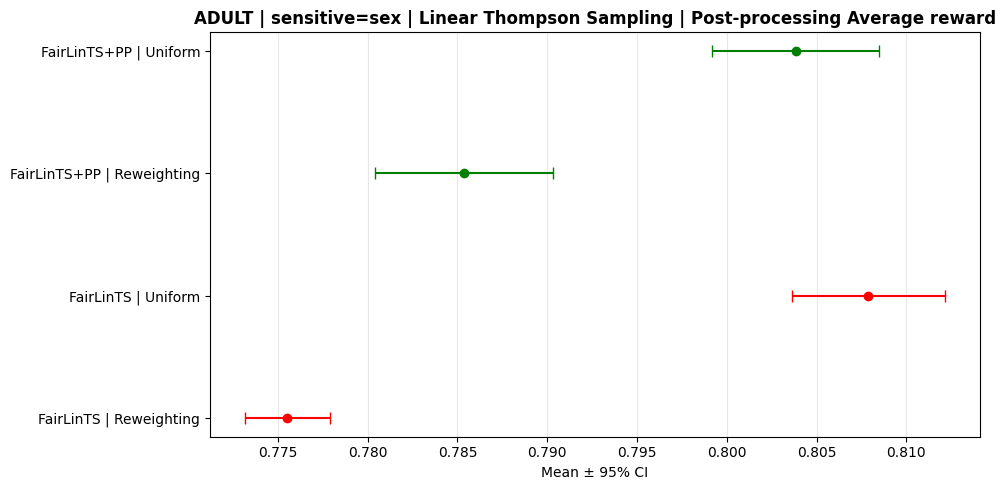

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_preprocessing_fairness.png


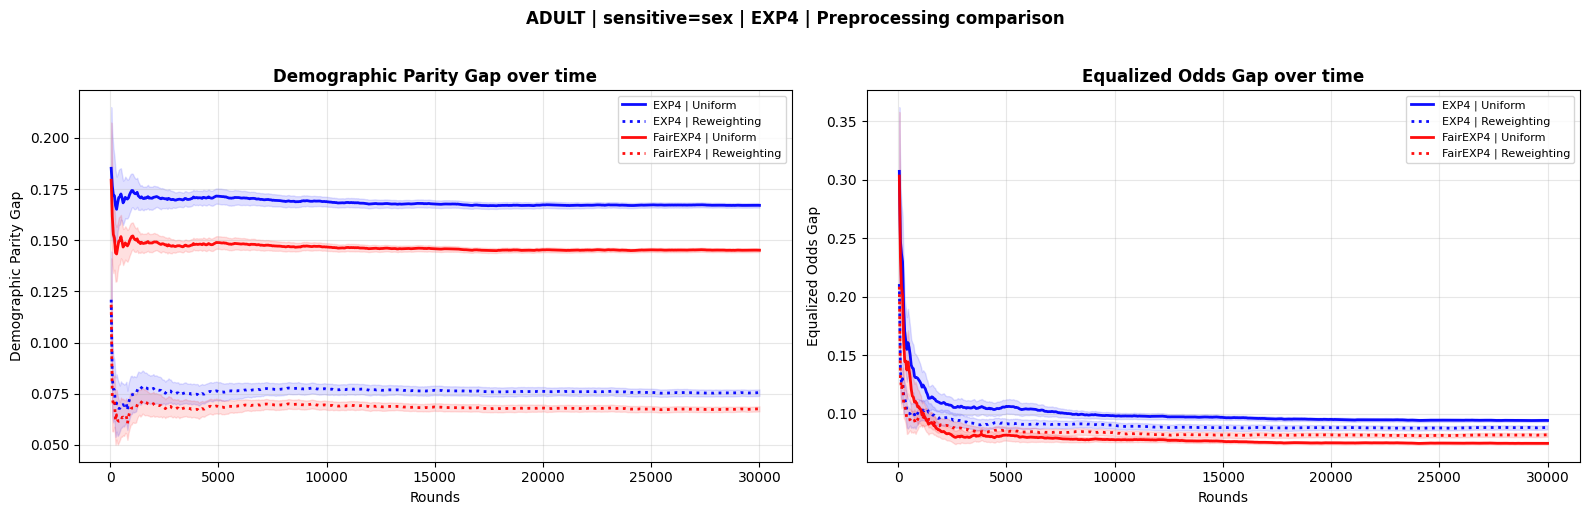

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_inprocessing_fairness.png


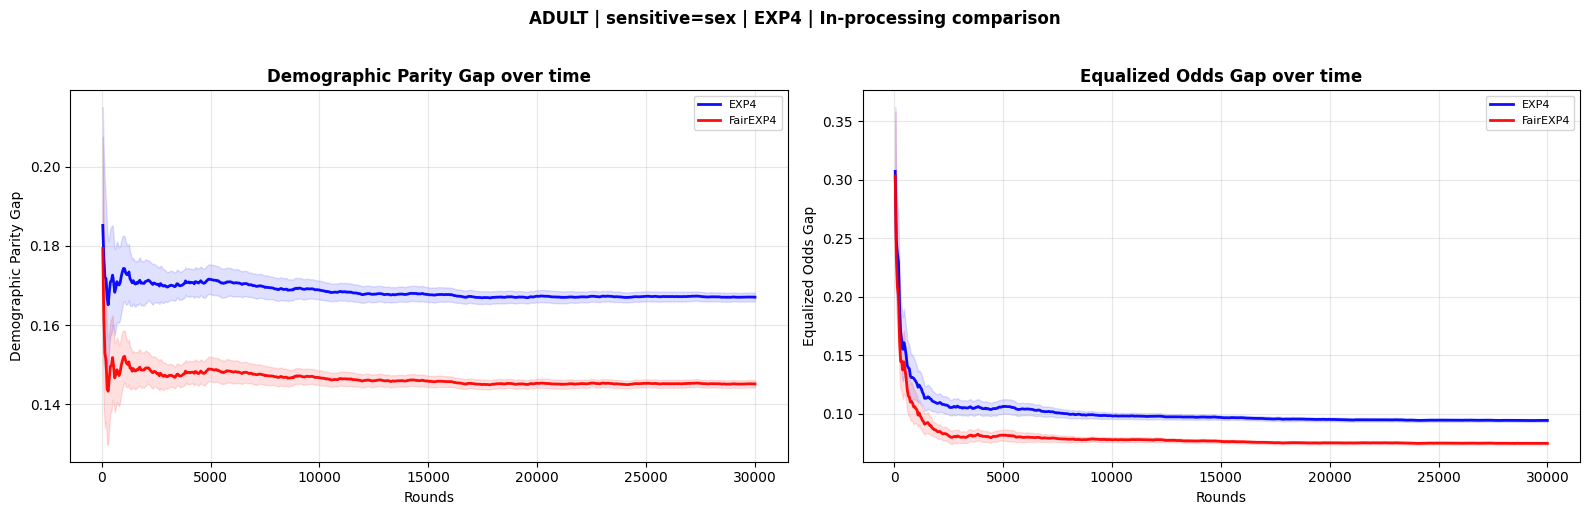

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_average_reward.png


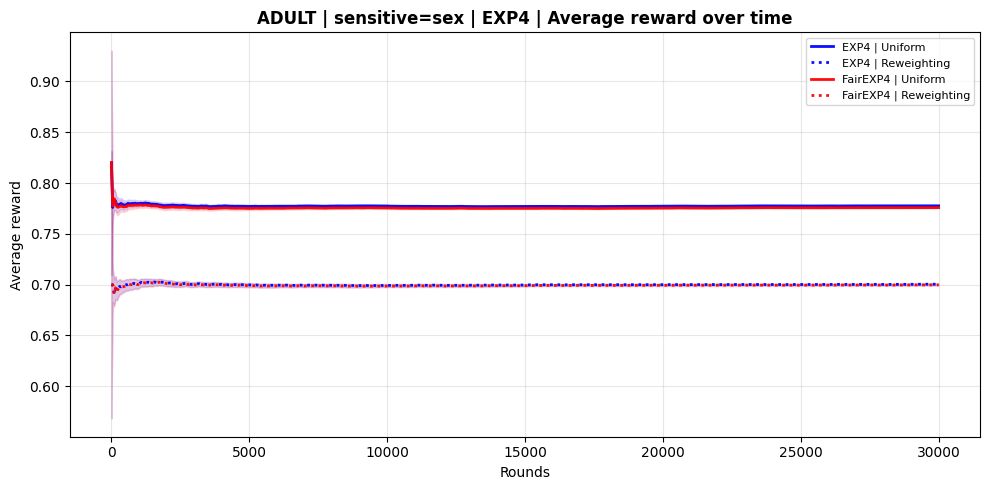

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_cumulative_prediction_error.png


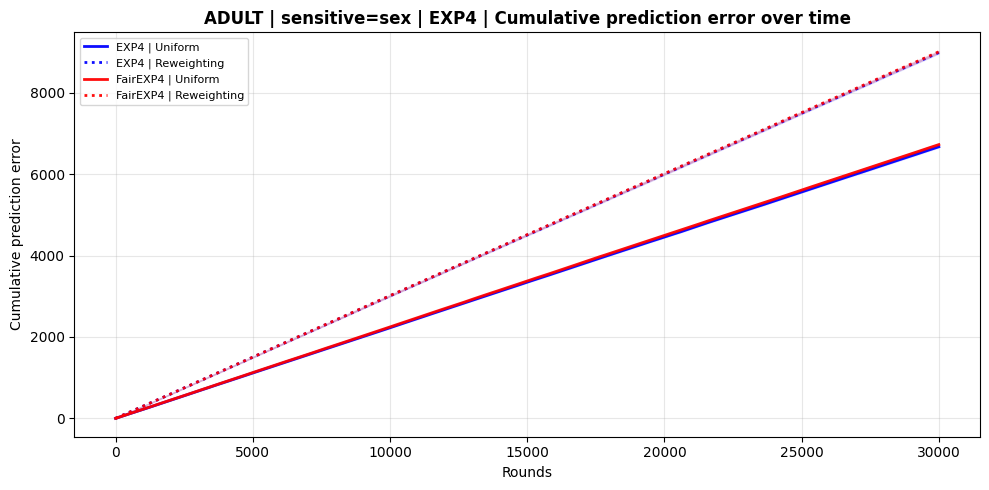

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_utility_gap.png


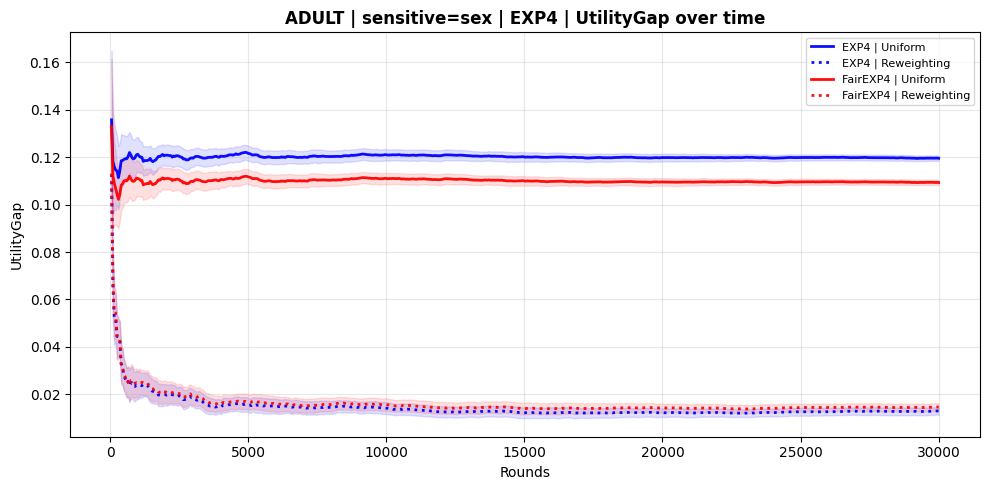

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_postprocessing_dp_gap.png


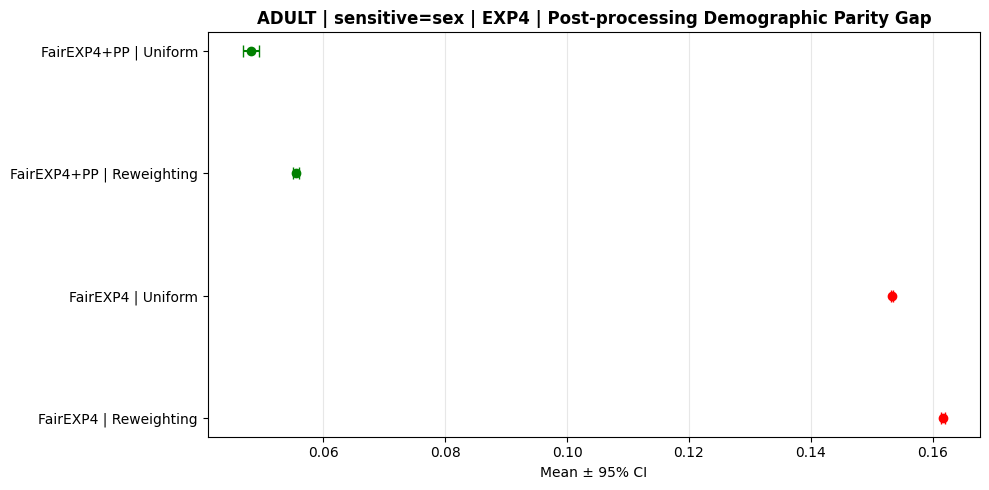

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_postprocessing_eo_gap.png


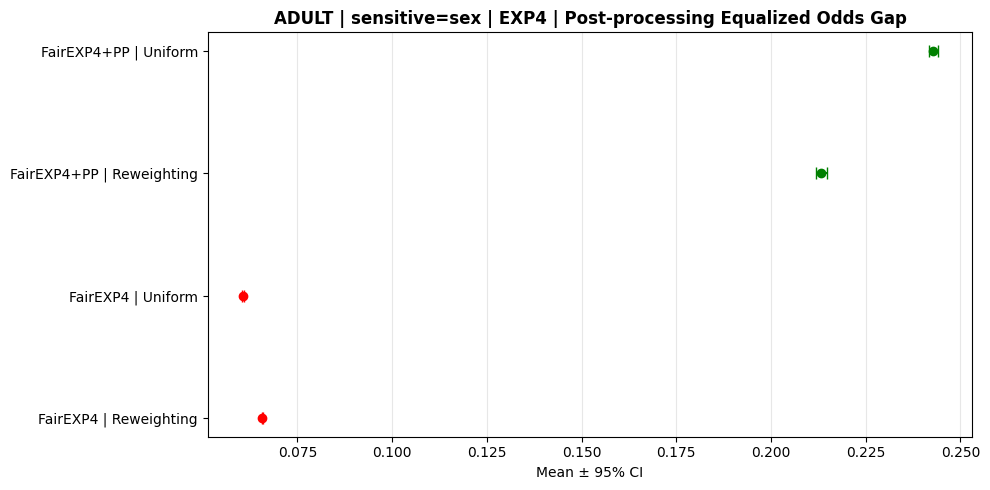

Saved: results\full\adult_sex_cmab_refactored\final_figures\adult_sex_exp4_postprocessing_average_reward.png


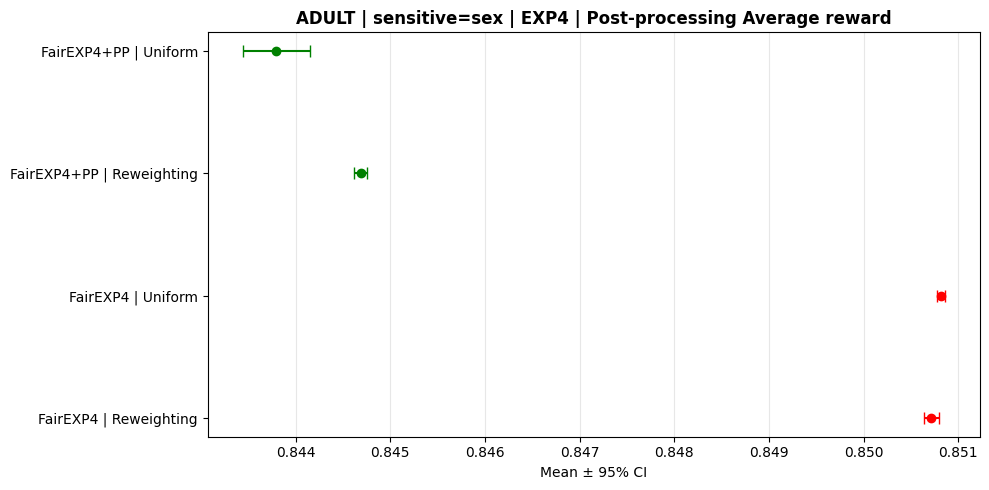

Generated figures: 24
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_preprocessing_fairness.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_inprocessing_fairness.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_average_reward.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_cumulative_prediction_error.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_utility_gap.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_postprocessing_dp_gap.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_postprocessing_eo_gap.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linucb_postprocessing_average_reward.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_preprocessing_fairness.png
results\full\adult_sex_cmab_refactored\final_figures\adult_sex_linear_ts_inprocessing_fairness.png
results\full\

In [28]:
figure_paths = []

for family, family_config in POLICY_FAMILIES.items():
    figure_paths.extend(
        plot_adult_family_figure_set(
            temporal_df=adult_temporal_df,
            family=family,
            family_label=family_config["label"],
            policies=family_config["policies"],
            preprocessings=PREPROCESSINGS,
            fig_dir=FIG_DIR,
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            show=True,
        )
    )

    figure_paths.extend(
        plot_adult_postprocessing_summary(
            postproc_df=adult_postproc_df,
            family=family,
            family_label=family_config["label"],
            fig_dir=FIG_DIR,
            policy_labels=POLICY_LABELS,
            preprocessing_labels=PREPROCESSING_LABELS,
            show=True,
        )
    )

print("Generated figures:", len(figure_paths))
for path in figure_paths:
    print(path)

## Final summary tables

This section exports compact final summary tables for the Adult-sex experiments.

The main utility table follows the thesis convention: average reward, cumulative prediction error, and UtilityGap are reported as the primary compact metrics. Fairness-specific metrics are exported separately when needed.

In [29]:
summary_tables = export_adult_final_summary_tables(
    endpoint_df=adult_endpoint_df,
    postproc_df=adult_postproc_df,
    table_dir=TABLE_DIR,
    families=POLICY_FAMILIES,
    preprocessings=PREPROCESSINGS,
    policy_labels=POLICY_LABELS,
    preprocessing_labels=PREPROCESSING_LABELS,
)

Saved: results\full\adult_sex_cmab_refactored\overleaf_tables\adult_sex_linucb_final_summary.csv
Saved: results\full\adult_sex_cmab_refactored\overleaf_tables\adult_sex_linucb_final_summary.tex
       Policy Preprocessing  Seeds      Average reward Cumulative prediction error          UtilityGap Demographic Parity Gap  Equalized Odds Gap
       LinUCB       Uniform     50 0.7826 $\pm$ 0.0380   6522.1200 $\pm$ 1141.4895 0.1513 $\pm$ 0.0841    0.2557 $\pm$ 0.1849 0.1958 $\pm$ 0.1763
       LinUCB   Reweighting     50 0.7279 $\pm$ 0.0323    8163.1600 $\pm$ 968.3982 0.1791 $\pm$ 0.0655    0.3585 $\pm$ 0.1014 0.2882 $\pm$ 0.1136
   FairLinUCB       Uniform     50 0.8055 $\pm$ 0.0214   3894.7500 $\pm$ 2082.4334 0.0958 $\pm$ 0.0365    0.0949 $\pm$ 0.0593 0.0850 $\pm$ 0.0817
   FairLinUCB   Reweighting     50 0.7599 $\pm$ 0.0451   4827.7300 $\pm$ 2723.3062 0.0628 $\pm$ 0.0418    0.1683 $\pm$ 0.0815 0.1329 $\pm$ 0.0616
FairLinUCB+PP       Uniform     50 0.8052 $\pm$ 0.0178    1902.5400 $\pm$ 17

## Paired significance tests

This section performs paired statistical comparisons across seeds.

The comparisons are defined separately for each policy family and cover the three intervention levels:

- preprocessing: baseline policy under uniform weighting versus reweighting;
- in-processing: baseline policy versus fairness-aware policy;
- post-processing: fairness-aware policy before versus after group-specific threshold calibration.

The tests are paired by seed and corrected for multiple comparisons using Holm correction.

In [30]:
SIGNIFICANCE_COMPARISONS_BY_FAMILY = {
    "linucb": [
        {
            "Comparison": "Preprocessing: LinUCB uniform vs reweighting",
            "baseline_policy": "LinUCB",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "LinUCB",
            "intervention_preprocessing": "reweigh_group_label",
        },
        {
            "Comparison": "In-processing: LinUCB vs FairLinUCB",
            "baseline_policy": "LinUCB",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "FairLinUCB",
            "intervention_preprocessing": "uniform",
        },
        {
            "Comparison": "Post-processing: FairLinUCB vs FairLinUCB+PP",
            "baseline_policy": "FairLinUCB",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "FairLinUCB+PP",
            "intervention_preprocessing": "uniform",
        },
    ],
    "linear_ts": [
        {
            "Comparison": "Preprocessing: LinTS uniform vs reweighting",
            "baseline_policy": "LinTS",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "LinTS",
            "intervention_preprocessing": "reweigh_group_label",
        },
        {
            "Comparison": "In-processing: LinTS vs FairLinTS",
            "baseline_policy": "LinTS",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "FairLinTS",
            "intervention_preprocessing": "uniform",
        },
        {
            "Comparison": "Post-processing: FairLinTS vs FairLinTS+PP",
            "baseline_policy": "FairLinTS",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "FairLinTS+PP",
            "intervention_preprocessing": "uniform",
        },
    ],
    "exp4": [
        {
            "Comparison": "Preprocessing: EXP4 uniform vs reweighting",
            "baseline_policy": "EXP4",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "EXP4",
            "intervention_preprocessing": "reweigh_group_label",
        },
        {
            "Comparison": "In-processing: EXP4 vs FairEXP4",
            "baseline_policy": "EXP4",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "FairEXP4",
            "intervention_preprocessing": "uniform",
        },
        {
            "Comparison": "Post-processing: FairEXP4 vs FairEXP4+PP",
            "baseline_policy": "FairEXP4",
            "baseline_preprocessing": "uniform",
            "intervention_policy": "FairEXP4+PP",
            "intervention_preprocessing": "uniform",
        },
    ],
}

significance_tables = export_adult_significance_tables(
    endpoint_df=adult_endpoint_df,
    postproc_df=adult_postproc_df,
    table_dir=TABLE_DIR,
    families=POLICY_FAMILIES,
    comparisons_by_family=SIGNIFICANCE_COMPARISONS_BY_FAMILY,
    policy_labels=POLICY_LABELS,
    preprocessing_labels=PREPROCESSING_LABELS,
)

Saved: results\full\adult_sex_cmab_refactored\overleaf_tables\adult_sex_linucb_significance_tests.csv
Saved: results\full\adult_sex_cmab_refactored\overleaf_tables\adult_sex_linucb_significance_tests.tex
                                  Comparison                      Metric             Baseline            Intervention      Baseline value Intervention value Holm p Sig.
Preprocessing: LinUCB uniform vs reweighting      Demographic Parity Gap     LinUCB | Uniform    LinUCB | Reweighting       0.256 ± 0.185      0.359 ± 0.101  0.003  Yes
Preprocessing: LinUCB uniform vs reweighting          Equalized Odds Gap     LinUCB | Uniform    LinUCB | Reweighting       0.196 ± 0.176      0.288 ± 0.114  0.004  Yes
Preprocessing: LinUCB uniform vs reweighting                  UtilityGap     LinUCB | Uniform    LinUCB | Reweighting       0.151 ± 0.084      0.179 ± 0.065  0.139   No
Preprocessing: LinUCB uniform vs reweighting              Average reward     LinUCB | Uniform    LinUCB | Reweighting   

## Generated artifacts

This final section lists the figures, LaTeX/CSV tables, and raw cached outputs generated by the notebook.

In [31]:
print("FIGURES")
for path in sorted(FIG_DIR.glob("adult_sex_*.png")):
    print(path.name)

print("\nTABLES")
for path in sorted(TABLE_DIR.glob("adult_sex_*")):
    print(path.name)

print("\nRAW RUN OUTPUTS")
for family in POLICY_FAMILIES:
    family_run_dir = RUN_DIR / family
    print("\nFamily:", family)
    for name in ["temporal.csv", "endpoint.csv", "postprocessing.csv", "postprocessing_parameters.csv"]:
        path = family_run_dir / name
        print(name, "exists =", path.exists(), "path =", path)

FIGURES
adult_sex_exp4_average_reward.png
adult_sex_exp4_cumulative_prediction_error.png
adult_sex_exp4_inprocessing_fairness.png
adult_sex_exp4_postprocessing_average_reward.png
adult_sex_exp4_postprocessing_dp_gap.png
adult_sex_exp4_postprocessing_eo_gap.png
adult_sex_exp4_preprocessing_fairness.png
adult_sex_exp4_utility_gap.png
adult_sex_linear_ts_average_reward.png
adult_sex_linear_ts_cumulative_prediction_error.png
adult_sex_linear_ts_inprocessing_fairness.png
adult_sex_linear_ts_postprocessing_average_reward.png
adult_sex_linear_ts_postprocessing_dp_gap.png
adult_sex_linear_ts_postprocessing_eo_gap.png
adult_sex_linear_ts_preprocessing_fairness.png
adult_sex_linear_ts_utility_gap.png
adult_sex_linucb_average_reward.png
adult_sex_linucb_cumulative_prediction_error.png
adult_sex_linucb_inprocessing_fairness.png
adult_sex_linucb_postprocessing_average_reward.png
adult_sex_linucb_postprocessing_dp_gap.png
adult_sex_linucb_postprocessing_eo_gap.png
adult_sex_linucb_preprocessing_fair